# Detekcija napada na mrežu
### Predmet: Sistemi za analizu i istraživanje podataka
 
**Skup podataka**: NSL-KDD (Network Security Laboratory & KDD)  
**Cilj**: Evaluacija i poređenje više klasifikatora za rešavanje problema napada na mrežu


### Značaj projekta

Usled velikog porasta internet korisnika i količine saobraćaja u prethodnim decenijama,
došlo je do čestog prisustva sajber kriminala. Kako bi se ovaj vid nezakonitih aktivnosti
smanjio, neophodno je razviti sisteme koji mogu da ih detektuju i precizno klasifikuju prema
vrsti.

**Zašto je ovo važno?**
- Štiti organizacije od finansijskih gubitaka
- Sprečava curenje osetljivih podataka
- Omogućava brzu reakciju na bezbednosne incidente
- Smanjuje potrebu za konstantnim ručnim nadzorom

**NSL-KDD dataset** je poboljšana verzija originalnog KDD Cup 1999 dataseta i široko se koristi u akademskim istraživanjima za testiranje algoritama detekcije napada.

## 1. Import potrebnih biblioteka

In [28]:
# Import standard libraries
import numpy as np
import pandas as pd
import os
import warnings
import time
import pickle
import joblib
from pathlib import Path

# Data preprocessing and analysis
import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedShuffleSplit

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## Uvod

**Glavni ciljevi projekta:**
- Analizirati NSL-KDD dataset i razumeti strukturu podataka
- Implementirati nekoliko modela mašinskog učenja
- Uporediti performanse različitih algoritama
- Identifikovati najoptimalniji model za detekciju napada

## 2. Učitavanje i analiza skupa podataka

NSL-KDD (Network Security Laboratory - Knowledge Discovery in Databases) je poznati skup podataka za detekciju mrežnih napada. Ovaj dataset sadrži 41 obeležje koja opisuju mrežni saobraćaj i omogućavaju razlikovanje normalnog saobraćaja od napada.

Skup podataka je već podaeljen na trening i test skup:
- **KDDTrain+.txt** 
- **KDDTest+.txt** 

In [29]:
# Define data paths and column names
import sklearn

DATA_PATH = Path('../data')

# NSL-KDD Feature names (41 features + 1 label + difficulty level)
FEATURE_NAMES = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
    'urgent', 'hot', 'num_failed_logins', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate'
]

# Attack type and difficulty level column
COLUMNS_WITH_LABELS = FEATURE_NAMES + ['attack_type', 'difficulty_level']

# Load training dataset
print("Loading training data...")
df_train = pd.read_csv(
    DATA_PATH / 'KDDTrain+.txt',
    header=None,
    names=COLUMNS_WITH_LABELS,
    engine='c'
)

print("Loading test data...")
df_test = pd.read_csv(
    DATA_PATH / 'KDDTest+.txt',
    header=None,
    names=COLUMNS_WITH_LABELS,
    engine='c'
)

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

# Display basic information
df_train

print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
print(f"\nData types:\n{df_train.dtypes}")

print(f"\nMissing values in training set:\n{df_train.isnull().sum().sum()}")
print(f"Missing values in test set:\n{df_test.isnull().sum().sum()}")


Loading training data...
Loading test data...
Training set shape: (125973, 42)
Test set shape: (22544, 42)

DATASET INFO

Data types:
duration                        object
protocol_type                   object
service                         object
flag                             int64
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_coun

## Eksplorativna analiza podataka (EDA)

Pre nego što krenemo sa modelovanjem, važno je razumeti strukturu i karakteristike podataka sa kojima radimo.

**EDA analiza:** Za eksplorativnu analizu podataka sa vizualizacijama pogledajte:
- **[eda.ipynb](eda.ipynb)**

U ovom notebook-u vršimo osnovnu analizu neophodnu za razumevanje strukture podataka pre modelovanja.

### Osnovne informacije o podacima

Iz osnovne statistike podataka možemo zaključiti:
- Nema nedostajućih vrednosti u datasetu
- Dataset sadrži i numerička i kategorijska obeležja
- Trening skup ima dovoljno instanci za kvalitetno treniranje modela

### Analiza distribucije napada

Analiza pokazuje koliko različitih tipova napada postoji u skupu podataka. NSL-KDD sadrži 5 glavnih kategorija:
1. **Normal** - normalan saobraćaj
2. **DoS** - Denial of Service napadi
3. **Probe** - napadi skeniranja
4. **R2L** - Remote to Local napadi
5. **U2R** - User to Root napadi

Za ovaj projekat vršimo **binarnu klasifikaciju**: Normal vs Attack (sve napade grupišemo u jednu klasu).

In [30]:
# Exploratory Data Analysis - Attack Type Distribution
print("\n" + "="*60)
print("ATTACK TYPE DISTRIBUTION")
print("="*60)

print("\nTraining Set - Attack Type Counts:")
print(df_train['attack_type'].value_counts())
print(f"\nTotal attack types: {df_train['attack_type'].nunique()}")

print("\nTest Set - Attack Type Counts:")
print(df_test['attack_type'].value_counts())

# Create binary classification (normal vs attack)
df_train_binary = df_train.copy()
df_test_binary = df_test.copy()

df_train_binary['class'] = (df_train['attack_type'] != 'normal').astype(int)
df_test_binary['class'] = (df_test['attack_type'] != 'normal').astype(int)

print("\n" + "="*60)
print("BINARY CLASSIFICATION DISTRIBUTION (Normal vs Attack)")
print("="*60)
print("\nTraining Set:")
print(df_train_binary['class'].value_counts())
print(f"Normal: {(df_train_binary['class']==0).sum()}, Attack: {(df_train_binary['class']==1).sum()}")

print("\nTest Set:")
print(df_test_binary['class'].value_counts())
print(f"Normal: {(df_test_binary['class']==0).sum()}, Attack: {(df_test_binary['class']==1).sum()}")


ATTACK TYPE DISTRIBUTION

Training Set - Attack Type Counts:
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Total attack types: 23

Test Set - Attack Type Counts:
attack_type
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess        

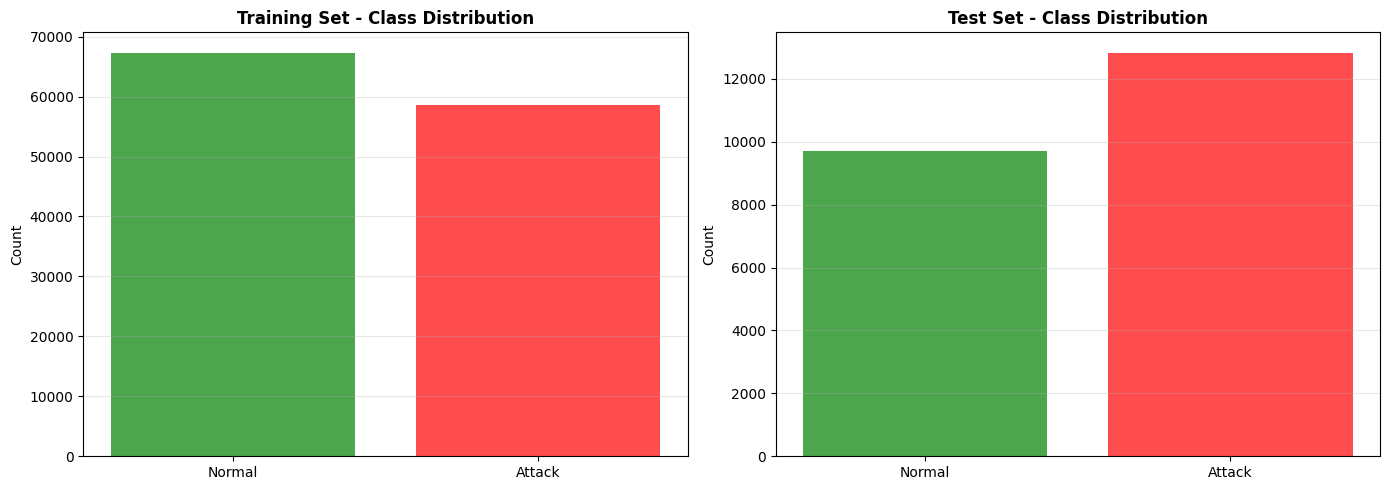

Class distribution visualization saved

PROTOCOL TYPE DISTRIBUTION
protocol_type
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64


In [31]:
# Visualization - Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for training set
class_counts_train = df_train_binary['class'].value_counts().sort_index()
axes[0].bar(['Normal', 'Attack'], class_counts_train.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Training Set - Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Bar plot for test set
class_counts_test = df_test_binary['class'].value_counts().sort_index()
axes[1].bar(['Normal', 'Attack'], class_counts_test.values, color=['green', 'red'], alpha=0.7)
axes[1].set_title('Test Set - Class Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Class distribution visualization saved")

# Protocol type distribution
print("\n" + "="*60)
print("PROTOCOL TYPE DISTRIBUTION")
print("="*60)
print(df_train['protocol_type'].value_counts())

### Vizualizacija distribucije klasa

Grafički prikaz nam omogućava da vidimo balans između normalnog saobraćaja i napada. Ovo je važno jer nebalansiranost klasa može uticati na performanse modela.

Iz grafika možemo zaključiti da li postoji značajna neravnoteža između klasa, a pošto to ovde nije slučaj nije potrebna primena dodatnih tehnika.

## 3. Čišćenje i priprema podataka (Data Preprocessing)

Pre treniranja modela, potrebno je:
1. **Proveriti nedostajuće vrednosti** - da li su svi podaci prisutni (već je provereno da nema null vrednosti)
2. **Ukloniti duplikate** - da izbegnemo bias u modelu
3. **Odbaciti nepotrebne kolone** - kao što su `attack_type` i `difficulty_level` jer vršimo binarnu klasifikaciju

Ovi koraci osiguravaju kvalitetne podatke za treniranje modela.

In [32]:
# Create working copies
df_train_prep = df_train_binary.copy()
df_test_prep = df_test_binary.copy()

# Check for duplicates
print(f"\nDuplicate rows in training set: {df_train_prep.duplicated().sum()}")
print(f"Duplicate rows in test set: {df_test_prep.duplicated().sum()}")

# Remove duplicates
if df_train_prep.duplicated().sum() > 0:
    print("Removing duplicates from training set...")
    df_train_prep = df_train_prep.drop_duplicates().reset_index(drop=True)

if df_test_prep.duplicated().sum() > 0:
    print("Removing duplicates from test set...")
    df_test_prep = df_test_prep.drop_duplicates().reset_index(drop=True)

print(f"\nAfter removing duplicates:")
print(f"Training set shape: {df_train_prep.shape}")
print(f"Test set shape: {df_test_prep.shape}")

# Drop unnecessary columns (attack_type details and difficulty level not needed for binary classification)
columns_to_drop = ['attack_type', 'difficulty_level']
df_train_prep = df_train_prep.drop(columns=columns_to_drop)
df_test_prep = df_test_prep.drop(columns=columns_to_drop)

print("\nData preprocessing completed")
print(f"Class distribution in training set:\n{df_train_prep['class'].value_counts().sort_index()}")


Duplicate rows in training set: 1255
Duplicate rows in test set: 128
Removing duplicates from training set...
Removing duplicates from test set...

After removing duplicates:
Training set shape: (124718, 43)
Test set shape: (22416, 43)

Data preprocessing completed
Class distribution in training set:
class
0    66999
1    57719
Name: count, dtype: int64


### Rezultati čišćenja podataka

Nakon preprocesiranja, podaci su spremni za dalje korake:
- Duplikati su uspešno uklonjeni
- Nema nedostajućih vrednosti
- Binarna klasifikacija je jasno definisana (Normal vs Attack)

## 4. Analiza obeležja i enkodiranje

Sada kada smo očistili podatke, prelazimo na transformaciju obeležja u format pogodan za algoritme mašinskog učenja.

In [33]:
# Identify categorical and numerical features
categorical_features = df_train_prep[FEATURE_NAMES].select_dtypes(include=['object']).columns.tolist()
numerical_features = df_train_prep[FEATURE_NAMES].select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"  - {feat}: {df_train_prep[feat].nunique()} unique values")

# Numerical features    
print(f"\nNumerical features ({len(numerical_features)}):")

# Encode categorical features
print("\n" + "="*60)
print("ENCODING CATEGORICAL FEATURES")
print("="*60)

# Apply one-hot encoding to all categorical features
all_encoded_dummies_train = pd.DataFrame()
all_encoded_dummies_test = pd.DataFrame()

for feature in categorical_features:
    print(f"Applying one-hot encoding to {feature}")
    
    # Create dummy variables for train and test
    dummies_train = pd.get_dummies(df_train_prep[feature], prefix=feature)
    dummies_test = pd.get_dummies(df_test_prep[feature], prefix=feature)
    
    # Ensure both train and test have the same columns
    all_columns = set(dummies_train.columns) | set(dummies_test.columns)
    for col in all_columns:
        if col not in dummies_train.columns:
            dummies_train[col] = 0
        if col not in dummies_test.columns:
            dummies_test[col] = 0
    
    # Reorder columns to match
    dummies_train = dummies_train[sorted(all_columns)]
    dummies_test = dummies_test[sorted(all_columns)]
    
    # Concatenate with the overall dummy dataframe
    all_encoded_dummies_train = pd.concat([all_encoded_dummies_train, dummies_train], axis=1)
    all_encoded_dummies_test = pd.concat([all_encoded_dummies_test, dummies_test], axis=1)

# Remove original categorical features from dataframes
df_train_prep = df_train_prep.drop(categorical_features, axis=1)
df_test_prep = df_test_prep.drop(categorical_features, axis=1)

# Remove categorical features from FEATURE_NAMES and add encoded ones
for feature in categorical_features:
    FEATURE_NAMES.remove(feature)

# Add all encoded categorical columns to dataframes
df_train_prep = pd.concat([df_train_prep, all_encoded_dummies_train], axis=1)
df_test_prep = pd.concat([df_test_prep, all_encoded_dummies_test], axis=1)

# Get all encoded feature names and add to FEATURE_NAMES
encoded_categorical_columns = sorted(all_encoded_dummies_train.columns.tolist())
FEATURE_NAMES.extend(encoded_categorical_columns)

print(f"\nTotal features after encoding: {len(FEATURE_NAMES)}")
print(f"Numerical: {len(numerical_features)}")
print(f"Categorical (One-Hot Encoded): {len(encoded_categorical_columns)}")

# Check data types after encoding
print("\nData types after encoding:")
print(df_train_prep[FEATURE_NAMES].dtypes.value_counts())

print(f"\nTraining set shape: {df_train_prep.shape}")
print(f"Test set shape: {df_test_prep.shape}")
print(f"\nUpdated FEATURE_NAMES ({len(FEATURE_NAMES)} features):")
print(FEATURE_NAMES)
print("\nFeature engineering and encoding completed")

Categorical features (3):
  - duration: 3 unique values
  - protocol_type: 70 unique values
  - service: 11 unique values

Numerical features (37):

ENCODING CATEGORICAL FEATURES
Applying one-hot encoding to duration
Applying one-hot encoding to protocol_type
Applying one-hot encoding to service

Total features after encoding: 121
Numerical: 37
Categorical (One-Hot Encoded): 84

Data types after encoding:
bool       84
int64      22
float64    15
Name: count, dtype: int64

Training set shape: (124718, 122)
Test set shape: (22416, 122)

Updated FEATURE_NAMES (121 features):
['flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'd

### Rezultat enkodiranja

NSL-KDD dataset sadrži i kategorijska obeležja (npr. `protocol_type`, `service`, `flag`) koja algoritmi mašinskog učenja ne mogu direktno da koriste.

Koristimo **One-Hot Encoding** za transformaciju kategorijskih obeležja u numeričke.
Nakon enkodiranja, broj obeležja se značajno povećava jer svaka kategorija dobija svoju kolonu. Ovo je normalno i očekivano kod one-hot encoding tehnike. Sada su sva obeležja numerička.

## 5. Priprema podataka za treniranje

Nakon enkodiranja kategorijskih obeležja, potrebno je razdvojiti podatke na:
- **Features (X)** - nezavisne promenljive koje model koristi
- **Target (y)** - zavisna promenljiva koju model predviđa

Koristimo već pripremljeni test skup umesto ručne podele, što je standardna praksa za NSL-KDD dataset i omogućava poređenje rezultata sa drugim studijama.

In [34]:
# Separate features and target from training set
X_train = df_train_prep[FEATURE_NAMES]
y_train = df_train_prep['class']

# Separate features and target from test set
X_test = df_test_prep[FEATURE_NAMES]
y_test = df_test_prep['class']


# Feature information
print("\nFeature Information:")
print("-"*60)
print(f"Total features: {len(FEATURE_NAMES)}")
print(f"Feature names: {FEATURE_NAMES}")

# Check for any remaining NaN values
print(f"\nNaN values in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN values in X_test: {X_test.isnull().sum().sum()}")

print("\nFeatures and target variables prepared successfully")


Feature Information:
------------------------------------------------------------
Total features: 121
Feature names: ['flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'duration_icmp', 'duration_tcp', 'duration_udp', 'protocol_type_IRC', 'protocol_type_X11', 'protocol_type_Z39_50', 'protocol_type_aol', 'protocol_type_auth', 'protocol_type_bgp', 'protocol_type_courier', 'p

## 6. Standardizacija podataka


Moramo uraditi standardizaciju jer obeležja imaju različite opsege vrednosti pa bi obeležja sa većim vrednostima imala veći uticaj:
- **duration** može biti od 0 do nekoliko hiljada
- **land** je binaran (0 ili 1)
- **src_bytes** može biti veoma veliki broj

Koristićemo StandardScaler za ovaj problem.

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to maintain feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_NAMES)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_NAMES)

# Verify scaling
print("\nScaled Data Statistics (Training Set):")
print("-"*60)
print(f"Min value: {X_train_scaled.min().min():.6f}")
print(f"Max value: {X_train_scaled.max().max():.6f}")
print(f"Mean: {X_train_scaled.mean().mean():.6f}")
print(f"Std: {X_train_scaled.std().mean():.6f}")


Scaled Data Statistics (Training Set):
------------------------------------------------------------
Min value: -2.105674
Max value: 353.152941
Mean: 0.000000
Std: 0.991740


## 7. Inicijalizacija modela

Koristimo 5 različitih algoritama za poređenje performansi:

1. **Logistic Regression** - linearan model
2. **Random Forest** - ansambl stabala odlučivanja
3. **SVM (Support Vector Machine)** - efikasan za velike dimenzije
4. **Gradient Boosting** - napredna tehnika ansambla
5. **Neural Network (MLP)** - klasifikator dubokog učenja

Svaki model je inicijalizovan sa podrazumevanim hiperparametrima. Kasnije ćemo optimizovati pomoću Grid Search-a ili Random Search-a.

In [36]:
print("Initializing machine learning models...\n")

# Initialize models with default hyperparameters
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs',
        verbose=0
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        verbose=0,
        max_depth=20
    ),
    
    'SVM (RBF Kernel)': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42,
        verbose=0
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        verbose=0
    ),
    
    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        batch_size=32,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=200,
        random_state=42,
        early_stopping=False,
        verbose=0
    )
}

print("Models Initialized:")
print("="*60)
for i, (name, model) in enumerate(models.items(), 1):
    print(f"\n{i}. {name}")
    print(f"   Type: {type(model).__name__}")
    print(f"   Parameters:")
    for param, value in model.get_params().items():
        if param not in ['n_jobs']:
            param_str = str(value)
            print(f"     {param}: {param_str}")


Initializing machine learning models...

Models Initialized:

1. Logistic Regression
   Type: LogisticRegression
   Parameters:
     C: 1.0
     class_weight: None
     dual: False
     fit_intercept: True
     intercept_scaling: 1
     l1_ratio: None
     max_iter: 1000
     multi_class: deprecated
     penalty: l2
     random_state: 42
     solver: lbfgs
     tol: 0.0001
     verbose: 0
     warm_start: False

2. Random Forest
   Type: RandomForestClassifier
   Parameters:
     bootstrap: True
     ccp_alpha: 0.0
     class_weight: None
     criterion: gini
     max_depth: 20
     max_features: sqrt
     max_leaf_nodes: None
     max_samples: None
     min_impurity_decrease: 0.0
     min_samples_leaf: 1
     min_samples_split: 2
     min_weight_fraction_leaf: 0.0
     monotonic_cst: None
     n_estimators: 100
     oob_score: False
     random_state: 42
     verbose: 0
     warm_start: False

3. SVM (RBF Kernel)
   Type: SVC
   Parameters:
     C: 1.0
     break_ties: False
     cach

## 8. Model Training

In [37]:
print("Training all models...\n")
print("="*60)

# To store trained models and training times
trained_models = {}
training_times = {}

for name, model in models.items():
    print(f"\nTraining: {name}")
    print("-" * 40)
    
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    end_time = time.time()
    
    training_time = end_time - start_time
    
    trained_models[name] = model
    training_times[name] = training_time
    
    print(f"Training completed in {training_time:.4f} seconds")

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)

# Sort by training time
sorted_times = sorted(training_times.items(), key=lambda x: x[1])

print("\nTraining Time for Each Model:")
print("-"*60)
for i, (name, duration) in enumerate(sorted_times, 1):
    print(f"{i}. {name:25s}: {duration:8.4f} seconds")

total_training_time = sum(training_times.values())
avg_training_time = total_training_time / len(training_times)

print(f"\nTotal training time: {total_training_time:.4f} seconds")

Training all models...


Training: Logistic Regression
----------------------------------------
Training completed in 4.9051 seconds

Training: Random Forest
----------------------------------------
Training completed in 4.7937 seconds

Training: SVM (RBF Kernel)
----------------------------------------
Training completed in 861.2321 seconds

Training: Gradient Boosting
----------------------------------------
Training completed in 47.8326 seconds

Training: Neural Network (MLP)
----------------------------------------
Training completed in 289.2956 seconds

TRAINING SUMMARY

Training Time for Each Model:
------------------------------------------------------------
1. Random Forest            :   4.7937 seconds
2. Logistic Regression      :   4.9051 seconds
3. Gradient Boosting        :  47.8326 seconds
4. Neural Network (MLP)     : 289.2956 seconds
5. SVM (RBF Kernel)         : 861.2321 seconds

Total training time: 1208.0591 seconds


## 9. Evaluacija modela


Sve trenirane modele evaluiramo na **test skupu**.

Evaluiramo svaki model korišćenjem standardnih metrika klasifikacije i generišemo detaljan izveštaj koji uključuje:
- Metrike (Accuracy, Precision, Recall, F1, ROC-AUC)
- Matrica konfuzije za vizuelnu analizu
- Detalji za svaku klasu

In [38]:
evaluation_results = {}

# Evaluate each model
for name, model in trained_models.items():
    print(f"Evaluating: {name}")
    print("-" * 50)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Get probabilities for ROC-AUC
    try:
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    except:
        roc_auc = None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # Store results
    evaluation_results[name] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba if 'y_pred_proba' in locals() else None,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': conf_matrix
    }
    
    # Print metrics
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"\nConfusion Matrix:")
    print(conf_matrix)
    print()


Evaluating: Logistic Regression
--------------------------------------------------
Accuracy:  0.7577
Precision: 0.9174
Recall:    0.6292
F1-Score:  0.7464
ROC-AUC:   0.7875

Confusion Matrix:
[[8991  720]
 [4711 7994]]

Evaluating: Random Forest
--------------------------------------------------
Accuracy:  0.7849
Precision: 0.9690
Recall:    0.6411
F1-Score:  0.7716
ROC-AUC:   0.9640

Confusion Matrix:
[[9450  261]
 [4560 8145]]

Evaluating: SVM (RBF Kernel)
--------------------------------------------------
Accuracy:  0.7911
Precision: 0.9256
Recall:    0.6866
F1-Score:  0.7884
ROC-AUC:   0.9066

Confusion Matrix:
[[9010  701]
 [3982 8723]]

Evaluating: Gradient Boosting
--------------------------------------------------
Accuracy:  0.8330
Precision: 0.9716
Recall:    0.7266
F1-Score:  0.8314
ROC-AUC:   0.9519

Confusion Matrix:
[[9441  270]
 [3474 9231]]

Evaluating: Neural Network (MLP)
--------------------------------------------------
Accuracy:  0.7959
Precision: 0.9327
Recall:    

In [39]:
# Detailed classification reports
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60)

for name, results in evaluation_results.items():
    print(f"\n{name}")
    print("-" * 60)
    print(classification_report(y_test, results['y_pred'], 
                                target_names=['Normal', 'Attack'],
                                zero_division=0))


DETAILED CLASSIFICATION REPORTS

Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.66      0.93      0.77      9711
      Attack       0.92      0.63      0.75     12705

    accuracy                           0.76     22416
   macro avg       0.79      0.78      0.76     22416
weighted avg       0.80      0.76      0.76     22416


Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.67      0.97      0.80      9711
      Attack       0.97      0.64      0.77     12705

    accuracy                           0.78     22416
   macro avg       0.82      0.81      0.78     22416
weighted avg       0.84      0.78      0.78     22416


SVM (RBF Kernel)
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.

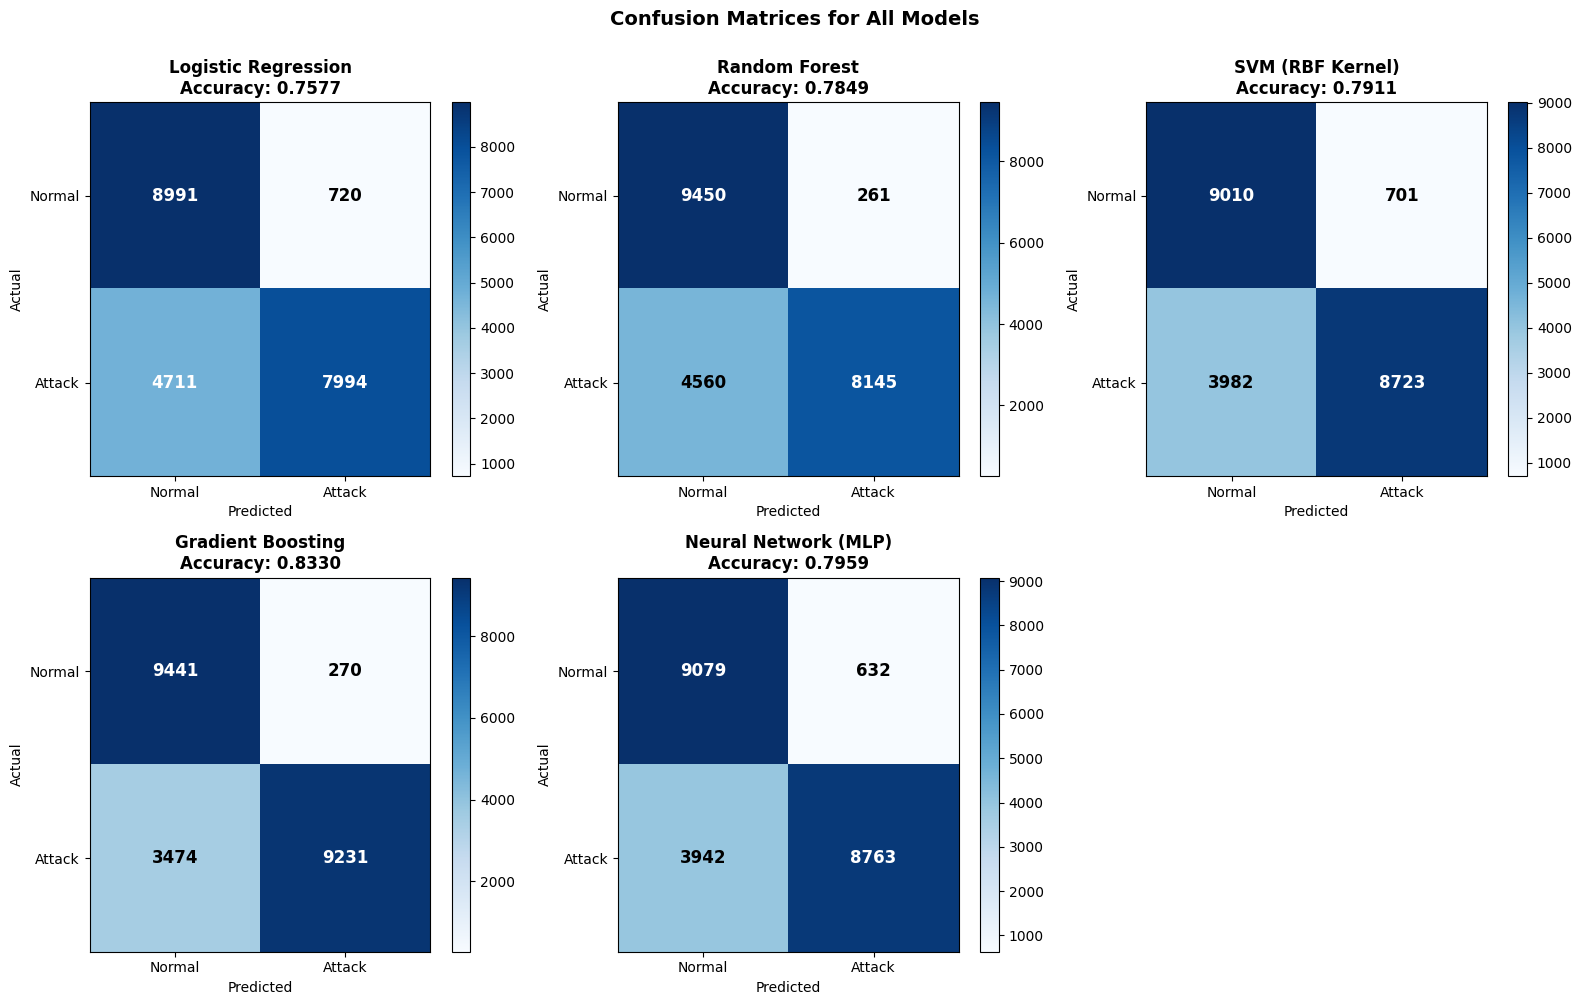

In [40]:
# Visualize confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, results) in enumerate(evaluation_results.items()):
    conf_matrix = results['confusion_matrix']
    
    # Plot confusion matrix
    im = axes[idx].imshow(conf_matrix, cmap='Blues', aspect='auto')
    axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]:.4f}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Normal', 'Attack'])
    axes[idx].set_yticklabels(['Normal', 'Attack'])
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = axes[idx].text(j, i, conf_matrix[i, j],
                                ha="center", va="center",
                                color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black",
                                fontsize=12, fontweight='bold')
    
    plt.colorbar(im, ax=axes[idx])

# Hide the extra subplot
axes[-1].axis('off')

plt.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

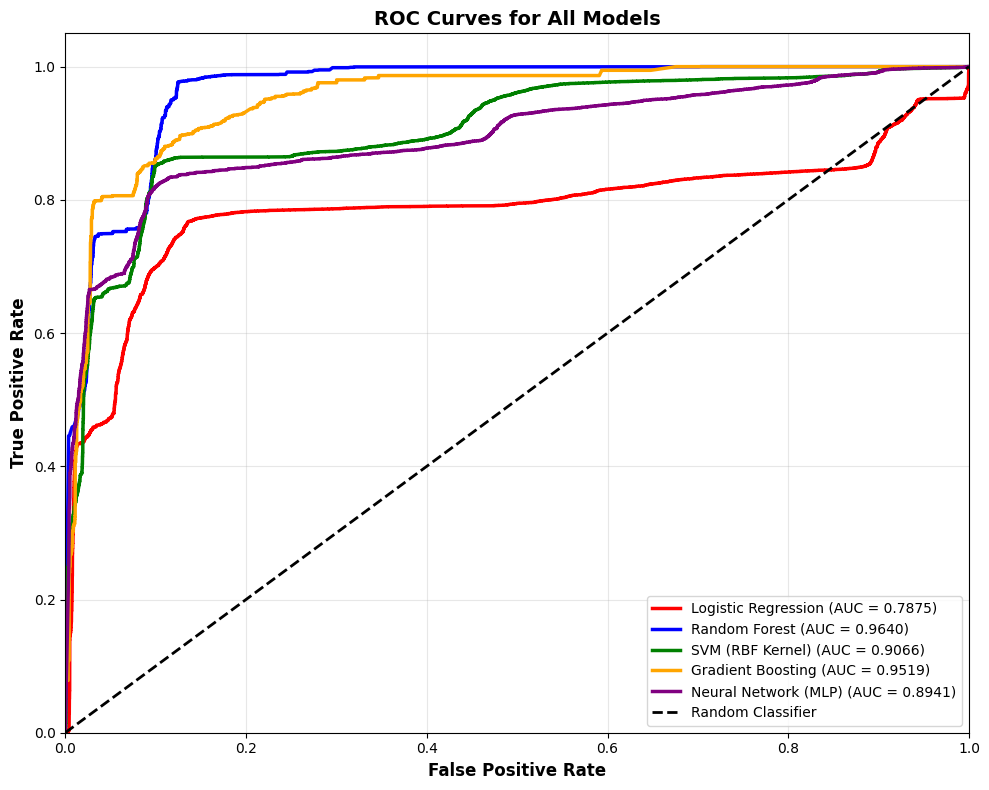

In [41]:
# Visualize ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red', 'blue', 'green', 'orange', 'purple']

for idx, (name, results) in enumerate(evaluation_results.items()):
    if results['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[idx], lw=2.5, 
                label=f'{name} (AUC = {auc_score:.4f})')
    else:
        print(f"Warning: {name} does not support probability predictions")

# Plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves for All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Poredjenje i analiza rezultata

In [42]:
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_data = []
for name, results in evaluation_results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'ROC-AUC': results['roc_auc'] if results['roc_auc'] is not None else 'N/A',
        'Training Time (s)': training_times[name]
    })

comparison_df = pd.DataFrame(comparison_data)

# Sort by accuracy
comparison_df_sorted = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\nPerformance Metrics Ranking by Accuracy:")
print("-"*80)
print(comparison_df_sorted.to_string(index=False))

# Find best and worst models
best_accuracy_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_accuracy_idx, 'Model']
best_accuracy = comparison_df.loc[best_accuracy_idx, 'Accuracy']

best_f1_idx = comparison_df['F1-Score'].idxmax()
best_f1_name = comparison_df.loc[best_f1_idx, 'Model']
best_f1 = comparison_df.loc[best_f1_idx, 'F1-Score']


print(f"\nBest F1-Score:  {best_f1_name} ({best_f1:.4f})")



MODEL COMPARISON

Performance Metrics Ranking by Accuracy:
--------------------------------------------------------------------------------
               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Training Time (s)
   Gradient Boosting  0.832976   0.971582 0.726564  0.831397 0.951886          47.832578
Neural Network (MLP)  0.795949   0.932730 0.689728  0.793032 0.894080         289.295612
    SVM (RBF Kernel)  0.791087   0.925615 0.686580  0.788377 0.906623         861.232090
       Random Forest  0.784930   0.968951 0.641086  0.771636 0.964018           4.793685
 Logistic Regression  0.757718   0.917374 0.629201  0.746440 0.787487           4.905128

Best F1-Score:  Gradient Boosting (0.8314)


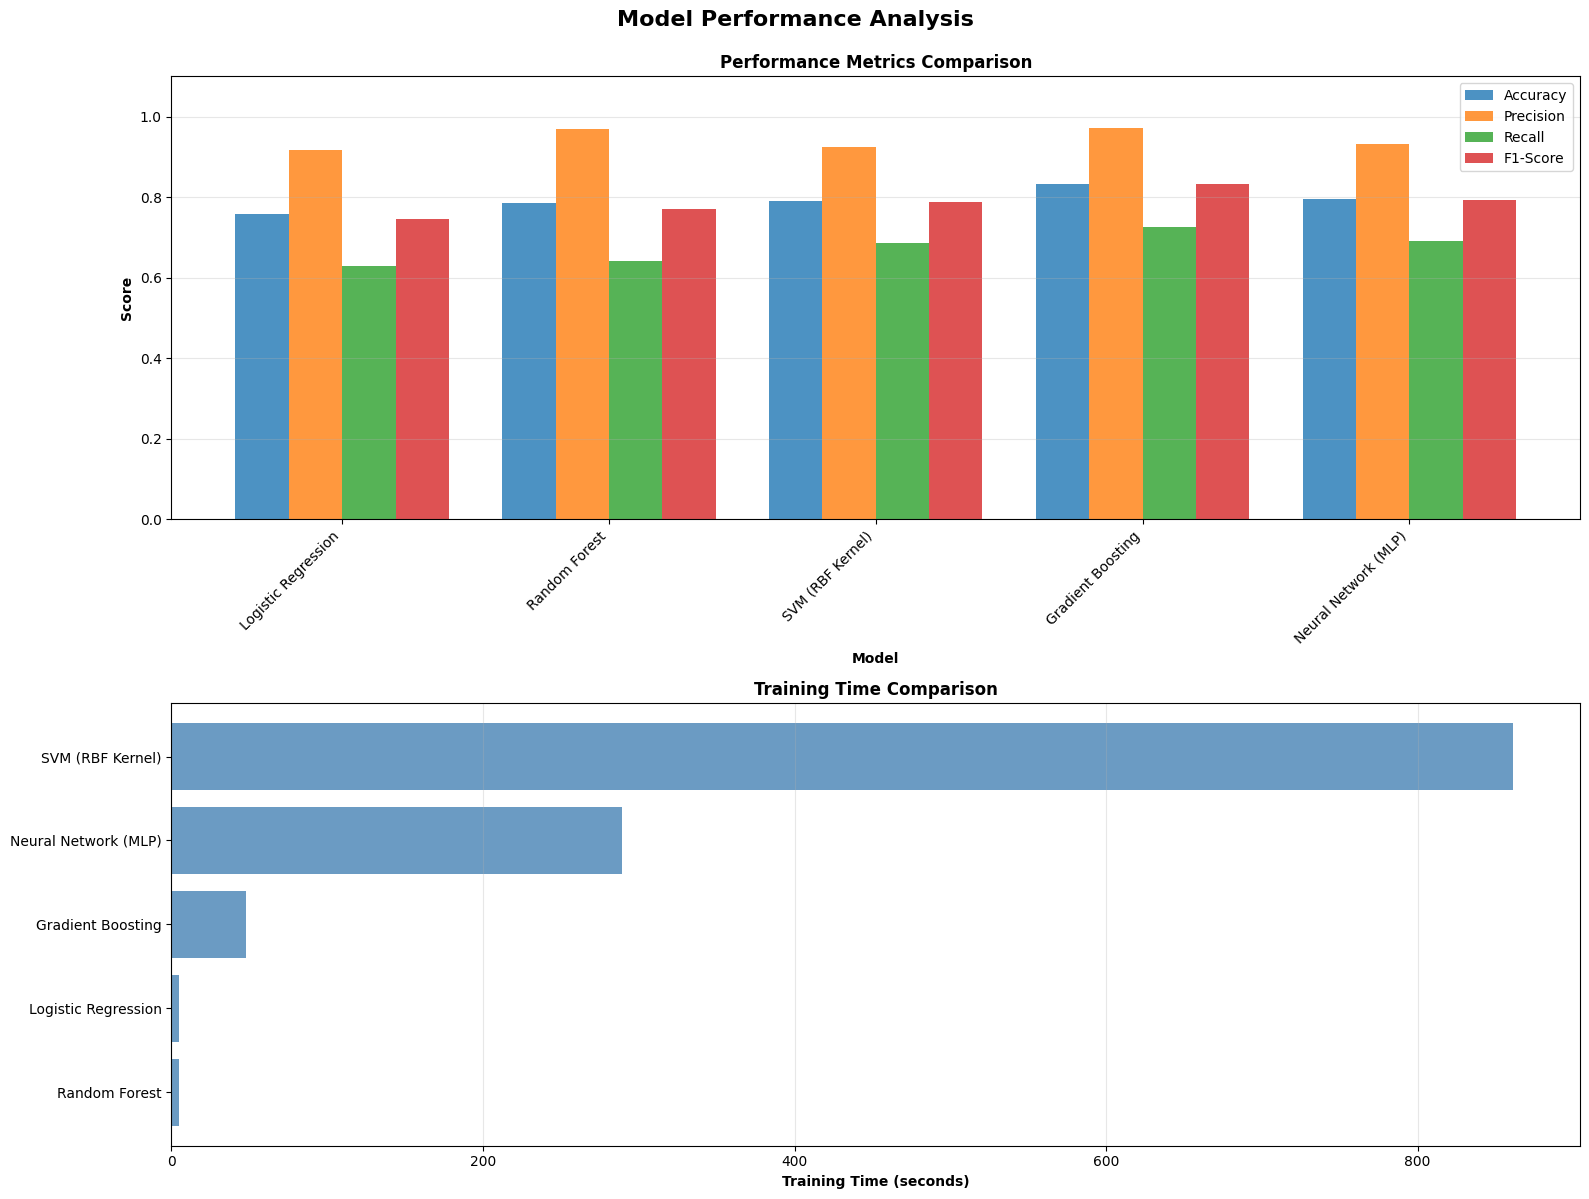

In [43]:
# Visualization - Model Performance Comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Prepare data for plotting
model_names = comparison_df['Model'].values
x_pos = np.arange(len(model_names))
width = 0.2

# Plot: Accuracy, Precision, Recall, F1-Score
ax = axes[0]
ax.bar(x_pos - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x_pos - 0.5*width, comparison_df['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x_pos + 0.5*width, comparison_df['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x_pos + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', alpha=0.8)
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Performance Metrics Comparison', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Plot: Training Time
ax = axes[1]
sorted_time = comparison_df.sort_values('Training Time (s)', ascending=True)
ax.barh(sorted_time['Model'], sorted_time['Training Time (s)'], color='steelblue', alpha=0.8)
ax.set_xlabel('Training Time (seconds)', fontweight='bold')
ax.set_title('Training Time Comparison', fontweight='bold')
ax.grid(axis='x', alpha=0.3)


plt.suptitle('Model Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Problemi

**Recall nije dovoljno visok (72.66% kod najboljeg modela)**
   - Još uvek propuštamo **27.34% napada** - ovo je previše za kritične sisteme

**Neoptimalnost hiperparametara**
   - Koristili smo default parametre za većinu modela
   - Nismo testirali različite kombinacije parametara



### Moguća unapređenja

1. **Threshold Optimization** - za povećanje Recall-a
2. **Hyperparameter tuning za Gradient Boosting** - Grid Search ili Random Search
3. **Feature Importance analiza** - dodatna identifikacija najvažnijih obeležja
4. **Cross-Validation** - za pouzdaniju evaluacija
5. **Dimensionality reduction** - PCA (Principal Component Analysis)
6. **Error Analysis** - detaljno ispitivanje grešaka